# Fase 4: Interpretabilidad

Explicar **por qué** el modelo predice lo que predice, y traducirlo a lenguaje de negocio.

Tres niveles de lectura:
1. **Global** — qué variables mueven el churn en toda la base (SHAP + coeficientes lineales).
2. **Por segmento** — qué caracteriza a cada uno de los 5 grupos de K-Means y qué acción pide.
3. **Individual** — por qué un cliente concreto recibe su score (SHAP local).

El modelo explicado es **XGBoost**, y esa elección condiciona lo que esta fase puede decir:
SHAP sobre un árbol describe la *forma* del efecto de cada variable —dónde satura, dónde hay
un umbral—, mientras que sobre un modelo lineal se reduce al coeficiente por el valor. La
regresión logística sigue presente, pero como **contraste independiente**, que es donde
aporta.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import shap

from sklearn.metrics import roc_auc_score

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))  # tfm_pipeline.py vive en src/, no junto al notebook
import tfm_pipeline as tfm

tfm.setup_notebook()

with open('../models/models_fase3.pkl', 'rb') as f:
    fase3 = pickle.load(f)

FEATURES = fase3['feature_columns']
CUTOFF, THRESHOLD = fase3['cutoff'], fase3['threshold']
NAMES = fase3['model_names']
BEST_KEY = fase3['best_model_key']
modelo = fase3[f'{BEST_KEY}_best']
preprocess = tfm.preprocess

data = pd.read_csv('../outputs/fase3_modeling/customer_data_with_clusters.csv', parse_dates=['observation_date'])
train = data[data['observation_date'] < CUTOFF]
test = data[data['observation_date'] >= CUTOFF]
X_train_s = fase3['scaler'].transform(preprocess(train[FEATURES]))
X_test_s = fase3['scaler'].transform(preprocess(test[FEATURES]))

print(f"Modelo interpretado: {NAMES[BEST_KEY]} ({type(modelo).__name__}) · umbral {THRESHOLD:.3f}")
print(f"Features ({len(FEATURES)}): {', '.join(FEATURES)}")
print(f"Test: {len(test):,} observaciones")

Modelo interpretado: XGBoost (XGBClassifier) · umbral 0.375
Features (7): recency_days, frequency, monetary, return_rate, customer_age_days, avg_items_per_transaction, unique_products
Test: 17,419 observaciones


## Interpretabilidad global — SHAP

Los valores SHAP se calculan sobre las features **escaladas**, así que el eje horizontal está
en desviaciones típicas. Lo que importa es el signo y la magnitud relativa.

El explicador se elige según el tipo de modelo ganador —`TreeExplainer` para los de árbol,
`LinearExplainer` para los lineales— en lugar de asumir uno fijo. Así el notebook sigue
funcionando si la Fase 3 selecciona otro modelo, que es precisamente lo que puede pasar cuando
cuatro algoritmos empatan dentro del ruido de la validación cruzada.

Explicador: TreeExplainer · matriz SHAP (17419, 7)


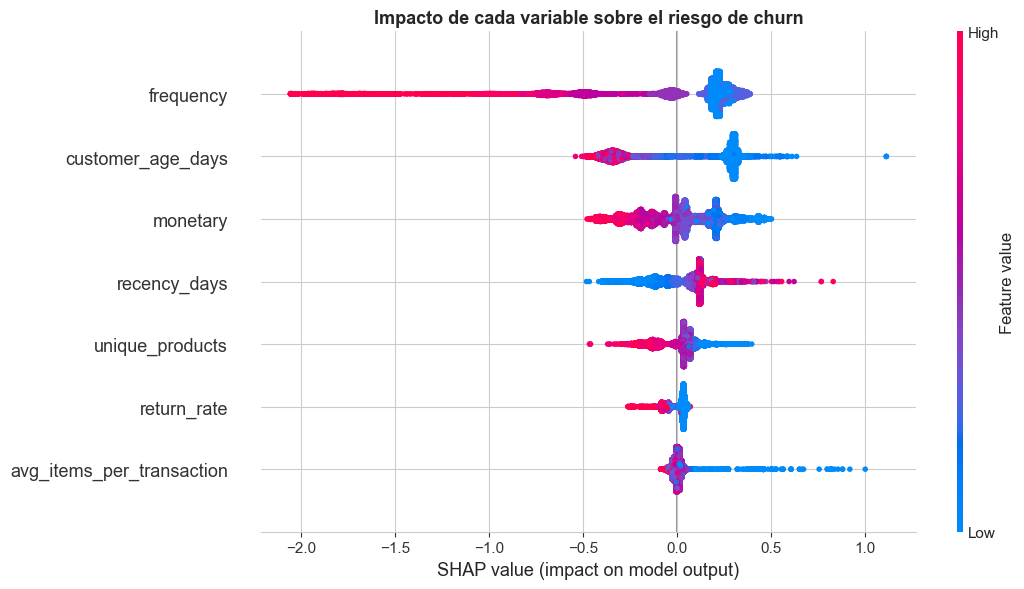

In [2]:
def construir_explainer(model, X_fondo):
    """Explicador adecuado al tipo de modelo, sin asumir que es de árbol."""
    if hasattr(model, 'feature_importances_'):
        return shap.TreeExplainer(model)
    return shap.LinearExplainer(model, X_fondo)


def shap_clase_positiva(valores):
    """Normaliza la salida de SHAP a una matriz (n_obs, n_features) de la clase 1."""
    if isinstance(valores, list):
        return np.asarray(valores[-1])
    valores = np.asarray(valores)
    return valores[:, :, -1] if valores.ndim == 3 else valores


explainer = construir_explainer(modelo, X_train_s)
shap_values = shap_clase_positiva(explainer.shap_values(X_test_s))
base_value = float(np.ravel(explainer.expected_value)[-1])

print(f"Explicador: {type(explainer).__name__} · matriz SHAP {shap_values.shape}")

shap.summary_plot(shap_values, X_test_s, feature_names=FEATURES, show=False, plot_size=(11, 6))
plt.title('Impacto de cada variable sobre el riesgo de churn', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [3]:
importancia = (pd.DataFrame({'Feature': FEATURES,
                             'SHAP medio |·|': np.abs(shap_values).mean(axis=0).astype(float)})
               .sort_values('SHAP medio |·|', ascending=False)
               .reset_index(drop=True))
importancia['SHAP medio |·|'] = importancia['SHAP medio |·|'].round(4)
importancia['% del total'] = (importancia['SHAP medio |·|'] / importancia['SHAP medio |·|'].sum() * 100).round(1)
print(importancia.to_string(index=False))

UMBRAL_DIRECCION_CLARA = 0.15  # |corr| por debajo de esto: efecto no monótono, no ruido

# Signo de la relación: correlación entre el valor de la feature y su contribución SHAP.
signo = {f: float(np.corrcoef(X_test_s[:, i], shap_values[:, i])[0, 1])
         for i, f in enumerate(FEATURES)}

print("\nDirección del efecto (correlación valor de la feature vs su SHAP):")
for f in importancia['Feature']:
    s = signo[f]
    if abs(s) < UMBRAL_DIRECCION_CLARA:
        flecha = 'sin dirección clara (efecto no monótono)'
    else:
        flecha = 'MÁS valor -> MÁS churn' if s > 0 else 'MÁS valor -> MENOS churn'
    print(f"  {f:30s} {s:+.2f}  {flecha}")

ES_LINEAL = hasattr(modelo, 'coef_')
if ES_LINEAL:
    print("\n  Nota: en un modelo lineal el SHAP de cada variable es proporcional a su valor,")
    print("  así que esta correlación vale ±1 por construcción y sólo informa del SIGNO del")
    print("  coeficiente. Lo informativo es la columna de importancia, no la fuerza de esta")
    print("  correlación. En un modelo de árbol el mismo diagnóstico sí detectaría efectos")
    print("  no monótonos, y por eso se mantiene: el notebook no asume qué modelo ganó.")

# Contraste marginal vs condicional: la correlación simple de una feature con el target
# puede tener signo distinto de su efecto condicional. Se declara explícitamente en vez
# de presentar sólo la señal que confirma la intuición.
# Con |corr| por debajo de este valor el signo es fruto del remuestreo, no una
# dirección: cambia según el subconjunto sobre el que se mida, y afirmar que
# «coincide» sería leer una coincidencia donde no hay nada que coincidir.
UMBRAL_SIGNO_ESTABLE = 0.01

print("\nCorrelación SIMPLE de cada feature con churn (efecto marginal, sin controlar el resto):")
marginal = test[FEATURES + ['churn']].corr()['churn'].drop('churn')
for f in importancia['Feature']:
    if abs(marginal[f]) < UMBRAL_SIGNO_ESTABLE:
        coincide = 'correlación nula: el signo no es estable entre subconjuntos'
    elif np.sign(marginal[f]) == np.sign(signo[f]):
        coincide = 'coincide con el condicional'
    else:
        coincide = 'SIGNO OPUESTO al condicional'
    print(f"  {f:30s} {marginal[f]:+.3f}  ({coincide})")

estables = [f for f in FEATURES if abs(marginal[f]) >= UMBRAL_SIGNO_ESTABLE]
opuestas = [f for f in estables if np.sign(marginal[f]) != np.sign(signo[f])]
print(f"\n  {len(estables)} de {len(FEATURES)} variables tienen signo estable, y "
      f"{'ninguna de ellas se invierte' if not opuestas else 'se invierten: ' + ', '.join(opuestas)}.")
print("  Importa para comunicar: una regla de una sola variable ('el cliente de una compra")
print("  es el de mayor riesgo') sólo se puede decir sin matices si el signo aguanta las dos")
print("  lecturas. Donde no aguanta es en la variable de menor peso, que ya salía sin")
print("  dirección clara en el diagnóstico de arriba — los dos avisos señalan a la misma.")

                  Feature  SHAP medio |·|  % del total
                frequency          0.3508         32.1
        customer_age_days          0.3066         28.1
                 monetary          0.1654         15.1
             recency_days          0.1190         10.9
          unique_products          0.0879          8.0
              return_rate          0.0428          3.9
avg_items_per_transaction          0.0198          1.8

Dirección del efecto (correlación valor de la feature vs su SHAP):
  frequency                      -0.91  MÁS valor -> MENOS churn
  customer_age_days              -0.91  MÁS valor -> MENOS churn
  monetary                       -0.87  MÁS valor -> MENOS churn
  recency_days                   +0.84  MÁS valor -> MÁS churn
  unique_products                -0.88  MÁS valor -> MENOS churn
  return_rate                    -0.90  MÁS valor -> MENOS churn
  avg_items_per_transaction      -0.50  MÁS valor -> MENOS churn

Correlación SIMPLE de cada feature con

### Lectura de negocio

El modelo no descubre nada exótico: reproduce la lógica RFM que cualquier responsable de
retención reconocería —comprar poco, hace mucho y con relación corta predice abandono—. Eso
es una señal de **validez**, no de trivialidad, y hace el modelo defendible ante quien tiene
que actuar sobre sus resultados.

**Pero el orden dentro del RFM no es el del manual, y merece declararse.** La *R* —la
recencia— es la variable que la literatura pone en primer lugar, y aquí queda **cuarta** por
SHAP, con un tercio del peso de `frequency`. Las medidas no dan todas el mismo puesto —quinta
por AUC univariante y por coeficiente logístico, segunda por correlación simple en bruto— pero
sí coinciden en lo que importa: ninguna la pone primera.

La explicación es de diseño, no de datos: dentro de una ventana de 6 meses la recencia está
acotada a ~183 días y el horizonte que se predice son 90. Entre un cliente que lleva 40 días
sin comprar y otro que lleva 70 hay poca diferencia de cara al trimestre siguiente; entre uno
que compró una vez y otro que compró siete, mucha. Traducido a la práctica: **la frecuencia
dice a quién contactar y la recencia dice cuándo** — y por eso las ventanas de intervención de
más abajo se construyen sobre la recencia aunque no sea la variable dominante.

**Un resultado contradice la intuición de partida:** la hipótesis inicial era que una tasa
alta de devoluciones anticipaba abandono, y ni la correlación simple de `return_rate` con el
churn ni su coeficiente en el modelo son positivos. La explicación es de composición: devolver
exige haber comprado, haber recibido el pedido y haber gestionado un retorno — es actividad,
no desafección. El efecto es además pequeño, así que el valor de la variable no está en el
modelo de churn sino en la **segmentación**, donde aísla un grupo con devoluciones en casi la
mitad de sus facturas: un problema de producto y operaciones, no de retención.

In [4]:
lectura = {
    'frequency': 'Cuántas veces compró en 6 meses (sin contar cancelaciones). Comprar una sola '
                 'vez es el perfil de mayor riesgo, y la tasa de abandono cae de forma sostenida '
                 'con cada compra adicional (ver tasas observadas más abajo).',
    'recency_days': 'Días desde la última compra. Cuanto más tiempo lleva sin comprar, más probable '
                    'es que no vuelva. Pesa menos de lo que el RFM clásico haría esperar porque la '
                    'ventana la acota a 6 meses; su papel aquí es fijar CUÁNDO intervenir, no a quién.',
    'customer_age_days': 'Días entre su primera y su última compra dentro de la ventana. Mide si la '
                         'relación está consolidada o si fue un episodio puntual.',
    'monetary': 'Gasto acumulado. El cliente que ya invirtió mucho tiende a seguir comprando.',
    'unique_products': 'Variedad de productos distintos. Más variedad = catálogo más explorado = '
                       'más razones para volver.',
    'avg_items_per_transaction': 'Unidades por pedido. Es la variable de menor peso y su '
                                 'correlación simple con el churn es prácticamente nula: el tamaño '
                                 'del pedido separa perfiles de compra, pero no dice casi nada '
                                 'sobre la permanencia.',
    'return_rate': 'Proporción de facturas con devolución. Contra la hipótesis inicial, se asocia a '
                   'MENOS abandono: devolver exige haber comprado y gestionado un retorno, luego '
                   'señala un cliente activo. Su utilidad está en la segmentación, no aquí.',
}

# El diccionario debe cubrir exactamente las features del modelo: si la Fase 2 añade o retira
# una variable, esta comprobación lo detecta en lugar de dejar una entrada muerta o un hueco.
assert set(lectura) == set(FEATURES), \
    f"lectura desincronizada. Sobran: {set(lectura) - set(FEATURES)}. Faltan: {set(FEATURES) - set(lectura)}"

for _, fila in importancia.iterrows():
    print(f"\n{fila['Feature']} ({fila['% del total']:.0f}% del impacto total)")
    print(f"  {lectura[fila['Feature']]}")


frequency (32% del impacto total)
  Cuántas veces compró en 6 meses (sin contar cancelaciones). Comprar una sola vez es el perfil de mayor riesgo, y la tasa de abandono cae de forma sostenida con cada compra adicional (ver tasas observadas más abajo).

customer_age_days (28% del impacto total)
  Días entre su primera y su última compra dentro de la ventana. Mide si la relación está consolidada o si fue un episodio puntual.

monetary (15% del impacto total)
  Gasto acumulado. El cliente que ya invirtió mucho tiende a seguir comprando.

recency_days (11% del impacto total)
  Días desde la última compra. Cuanto más tiempo lleva sin comprar, más probable es que no vuelva. Pesa menos de lo que el RFM clásico haría esperar porque la ventana la acota a 6 meses; su papel aquí es fijar CUÁNDO intervenir, no a quién.

unique_products (8% del impacto total)
  Variedad de productos distintos. Más variedad = catálogo más explorado = más razones para volver.

return_rate (4% del impacto total)
  Pr

## Cómo actúa cada variable

Las barras son **tasas de churn observadas** por tramo, no la curva del modelo. Esa es la
comparación que tiene valor: los `dependence_plot` de arriba son lo que el modelo **cree** y
estas barras lo que **pasó**. Que ambos cuenten la misma historia es la comprobación de que no
ha aprendido un artefacto.

Aquí se cobra la elección de un modelo de árbol en la Fase 3. XGBoost tiene libertad para
representar umbrales, saturaciones y cambios de pendiente; si los datos los tuvieran,
aparecerían como escalones. Lo que se ve son curvas que decaen de forma sostenida, y eso
convierte una suposición en una **verificación**: el empate de los cuatro modelos no era falta
de ajuste, es que no hay estructura no lineal apreciable que un árbol pueda explotar.

La excepción es `avg_items_per_transaction`, cuya correlación valor↔SHAP (−0,50) queda muy por
debajo de la del resto: su efecto **no es monótono**. Es también la variable de menor peso
—1,8%—, así que no mueve el ranking de la base, pero conviene no confundir peso medio con
irrelevancia: en la explicación individual de más abajo es el mayor aporte del cliente de más
riesgo. Un promedio pequeño puede esconder efectos grandes en los extremos, y eso es
exactamente lo que un modelo lineal no puede representar.

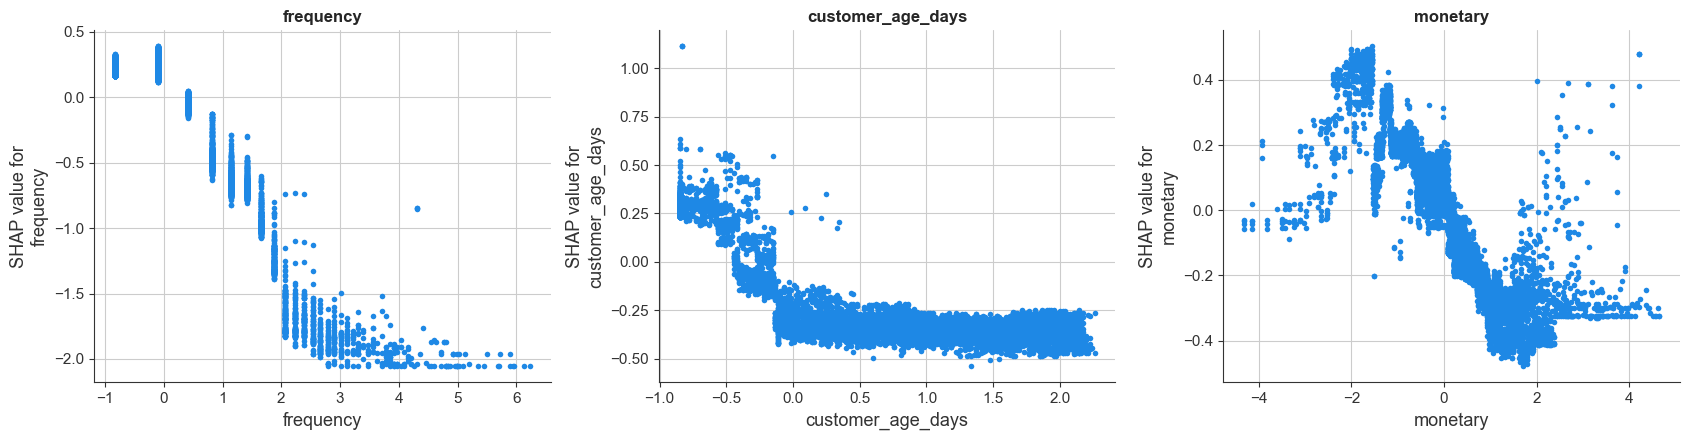

In [5]:
top3 = importancia['Feature'].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, feature in zip(axes, top3):
    shap.dependence_plot(FEATURES.index(feature), shap_values, X_test_s,
                         feature_names=FEATURES, ax=ax, show=False, interaction_index=None)
    ax.set_title(feature, fontweight='bold')
plt.tight_layout(); plt.show()

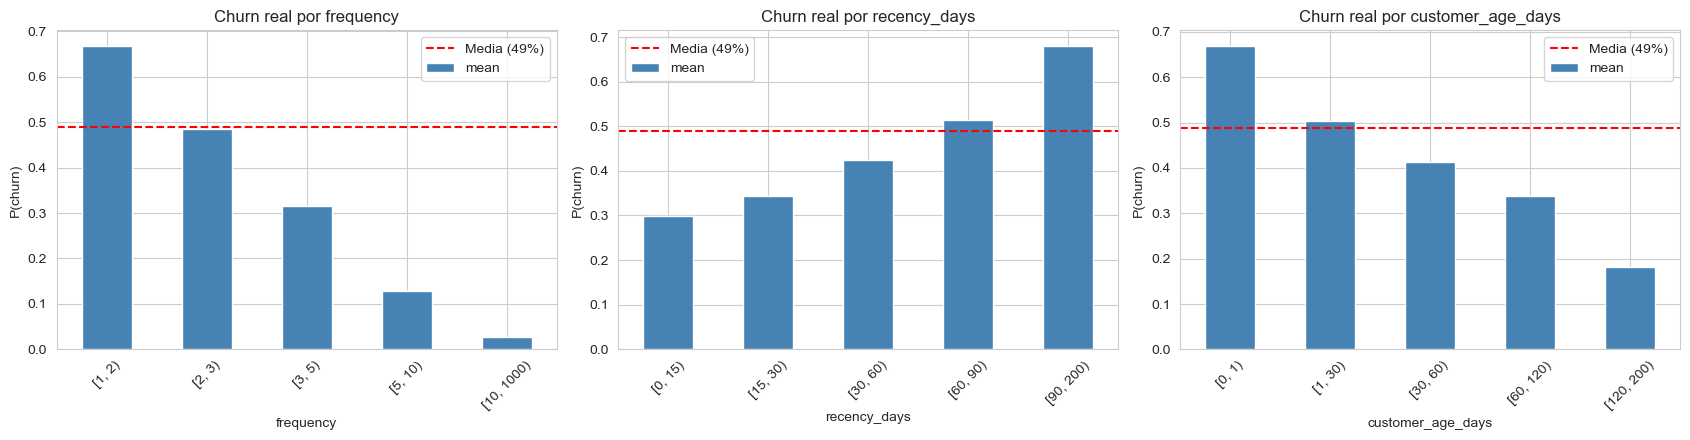

frequency: de 67% a 3% de churn entre el primer y el último tramo
recency_days: de 30% a 68% de churn entre el primer y el último tramo
customer_age_days: de 67% a 18% de churn entre el primer y el último tramo


In [6]:
# Los ejes SHAP están escalados; esta tabla traduce el efecto a unidades reales de negocio.
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
cortes = {
    'frequency': [1, 2, 3, 5, 10, 1000],
    'recency_days': [0, 15, 30, 60, 90, 200],
    'customer_age_days': [0, 1, 30, 60, 120, 200],
}
for ax, (feature, bins) in zip(axes, cortes.items()):
    tasa = test.groupby(pd.cut(test[feature], bins, right=False), observed=False)['churn'].agg(['mean', 'size'])
    tasa['mean'].plot(kind='bar', ax=ax, color='steelblue')
    ax.axhline(test['churn'].mean(), color='red', ls='--', label=f"Media ({test['churn'].mean():.0%})")
    ax.set(title=f'Churn real por {feature}', ylabel='P(churn)')
    ax.tick_params(axis='x', rotation=45); ax.legend()
plt.tight_layout(); plt.show()

for feature, bins in cortes.items():
    t = test.groupby(pd.cut(test[feature], bins, right=False), observed=False)['churn'].mean()
    print(f"{feature}: de {t.iloc[0]:.0%} a {t.iloc[-1]:.0%} de churn entre el primer y el último tramo")

## Contraste con el modelo lineal

El modelo de producción es XGBoost, pero la regresión logística de la Fase 3 gana aquí su
función: **es una segunda fuente de evidencia, independiente de SHAP**.

El razonamiento importa. SHAP calculado sobre un modelo lineal devuelve el signo del
coeficiente por construcción, de modo que el contraste sería tautológico. Calculado sobre un
árbol, los coeficientes de la logística son un instrumento distinto midiendo lo mismo: si
coinciden en signo y en orden de importancia, la conclusión no depende de la técnica elegida.

ROC-AUC en test:
  LightGBM               0.749
  XGBoost                0.749   <- seleccionado por CV
  Random Forest          0.749
  Logistic Regression    0.747

Diferencia entre el mejor y el peor: 0.002 — dentro del ruido de la CV.
Por eso la logística sirve de contraste: predice prácticamente lo mismo que el modelo
elegido, así que sus coeficientes describen el mismo fenómeno con otra técnica.


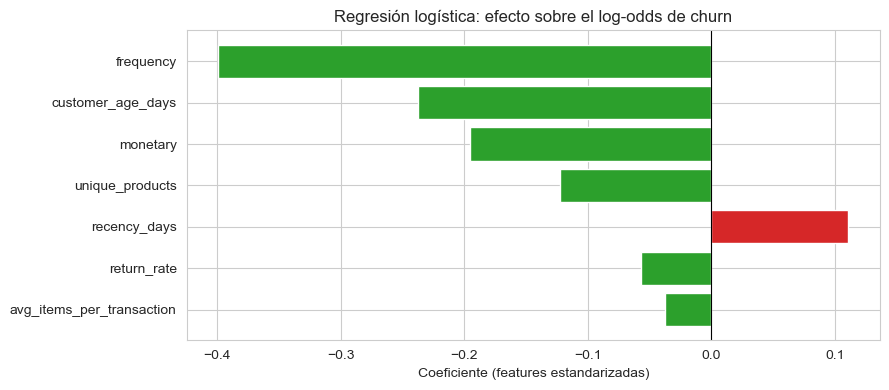


                  Feature  Coeficiente  Odds ratio        Efecto
                frequency       -0.399       0.671  reduce churn
        customer_age_days       -0.237       0.789  reduce churn
                 monetary       -0.195       0.823  reduce churn
          unique_products       -0.122       0.885  reduce churn
             recency_days        0.111       1.117 aumenta churn
              return_rate       -0.057       0.944  reduce churn
avg_items_per_transaction       -0.038       0.963  reduce churn

Odds ratio: cuánto se multiplica la probabilidad relativa de churn por cada
desviación típica de aumento en la variable.


In [7]:
lr = fase3['lr_best']

auc = {k: roc_auc_score(test['churn'], fase3[f'{k}_best'].predict_proba(X_test_s)[:, 1])
       for k in NAMES}
print("ROC-AUC en test:")
for k, v in sorted(auc.items(), key=lambda t: -t[1]):
    print(f"  {NAMES[k]:22s} {v:.3f}" + ("   <- seleccionado por CV" if k == BEST_KEY else ""))
print(f"\nDiferencia entre el mejor y el peor: {max(auc.values()) - min(auc.values()):.3f} "
      "— dentro del ruido de la CV.")
print("Por eso la logística sirve de contraste: predice prácticamente lo mismo que el modelo\n"
      "elegido, así que sus coeficientes describen el mismo fenómeno con otra técnica.")

coefs = (pd.DataFrame({'Feature': FEATURES, 'Coeficiente': lr.coef_[0]})
         .assign(**{'Odds ratio': lambda d: np.exp(d['Coeficiente']).round(3),
                    'Efecto': lambda d: np.where(d['Coeficiente'] > 0, 'aumenta churn', 'reduce churn')})
         .sort_values('Coeficiente', key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if c > 0 else '#2ca02c' for c in coefs['Coeficiente']]
ax.barh(coefs['Feature'][::-1], coefs['Coeficiente'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set(xlabel='Coeficiente (features estandarizadas)', title='Regresión logística: efecto sobre el log-odds de churn')
plt.tight_layout(); plt.show()

print(f"\n{coefs.round(3).to_string(index=False)}")
print("\nOdds ratio: cuánto se multiplica la probabilidad relativa de churn por cada")
print("desviación típica de aumento en la variable.")

## Perfiles de segmento

Los 5 grupos de K-Means, nombrados a partir de su perfil real. El perfil numérico se **lee**
del que calculó la Fase 3 (`segment_profiles_fase3.csv`) en vez de recalcularse aquí: una sola
definición, imposible que las dos versiones discrepen.

Los nombres se derivan por reglas sobre las métricas, no se asignan a mano, para que sigan
siendo válidos si el modelo se reentrena. Cada regla **reclama como máximo un cluster** de los
que siguen libres, de modo que la unicidad de los nombres está garantizada por construcción y
no depende de que los umbrales no se solapen.

In [8]:
perfil = pd.read_csv('../outputs/fase3_modeling/segment_profiles_fase3.csv', index_col='cluster')


def nombrar_segmentos(perfil):
    """Asigna un nombre por cluster mediante reglas de reclamación por rango.

    Cada regla toma, de entre los clusters aún libres que cumplen su condición, el
    que mejor puntúa en su criterio, y lo retira del conjunto. Así ningún nombre
    puede repetirse aunque dos clusters cumplan la misma condición, y las reglas
    que no encuentran candidato simplemente no se aplican — que es lo que debe
    pasar cuando un perfil deja de existir tras un reentrenamiento.
    """
    libres = list(perfil.index)
    nombres = {}

    def reclamar(nombre, criterio, condicion=None):
        candidatos = [c for c in libres if condicion is None or condicion(perfil.loc[c])]
        if not candidatos:
            return
        elegido = max(candidatos, key=lambda c: criterio(perfil.loc[c]))
        nombres[elegido] = nombre
        libres.remove(elegido)

    # Perfiles definidos por una anomalía de comportamiento...
    reclamar('Devoluciones crónicas', lambda f: f.return_rate, lambda f: f.return_rate > 0.55)
    reclamar('VIP / mayorista', lambda f: f.frequency, lambda f: f.frequency >= 8)
    reclamar('Devoluciones frecuentes', lambda f: f.return_rate, lambda f: f.return_rate > 0.25)
    # ...y el resto, por su posición en el eje lealtad-valor.
    reclamar('Regulares consolidados', lambda f: -f.churn_rate)
    # Se reclama por gasto entre los perfiles de compra puntual (frecuencia < 2). El nombre
    # dice «gasto alto» sólo respecto de los otros compradores puntuales, que es lo único que
    # el dato sostiene: hay segmentos con ticket medio mayor, pero no son compradores puntuales.
    reclamar('Compradores puntuales de gasto alto', lambda f: f.monetary,
             lambda f: f.frequency < 2)
    reclamar('Compradores puntuales', lambda f: f.churn_rate)
    for i, c in enumerate(sorted(libres)):
        nombres[c] = f'Segmento intermedio {i + 1}'
    return pd.Series(nombres).reindex(perfil.index)


perfil['segmento'] = nombrar_segmentos(perfil)
assert perfil.segmento.is_unique, "dos clusters comparten nombre de segmento"

# Los nombres afirman cosas; estas aserciones comprueban que el perfil las sostiene.
for cl, nombre in perfil.segmento.items():
    f = perfil.loc[cl]
    if 'gasto alto' in nombre:
        # La comparación es contra los OTROS segmentos de compra puntual, que son los que
        # el nombre pone implícitamente como referencia.
        otros = perfil[perfil.segmento.str.startswith('Compradores puntuales') &
                       (perfil.index != cl)]
        assert otros.empty or f.monetary > otros.monetary.max(), \
            f"«{nombre}» no gasta más que los otros compradores puntuales"
    if 'Devoluciones' in nombre:
        assert f.return_rate == perfil.return_rate.max(), \
            f"«{nombre}» no es el de mayor tasa de devolución"
    if 'VIP' in nombre:
        assert f.frequency == perfil.frequency.max(), f"«{nombre}» no es el más frecuente"

acciones = {
    'VIP / mayorista': 'Gestión de cuenta dedicada. Concentran el grueso del revenue con el churn '
                       'más bajo: el riesgo no es que se vayan, es que nadie los atienda.',
    'Regulares consolidados': 'Núcleo del negocio. Programa de fidelización estándar y vigilancia '
                              'de la recencia: son los que más valor pierden al caer.',
    'Compradores puntuales de gasto alto': 'Compraron una vez y por un importe relevante — varias '
                                           'veces el gasto del otro grupo de compra puntual. Es el '
                                           'segmento con mayor retorno potencial de una campaña de '
                                           'reactivación: ya demostraron capacidad de gasto.',
    'Compradores puntuales': 'Una compra pequeña y sin repetición. Reactivación por canales '
                             'automáticos: el coste de un contacto personalizado no se recupera.',
    'Devoluciones frecuentes': 'Compran poco —menos que la media de la base— y registran una '
                               'devolución en casi la mitad de sus facturas: casi una devolución por '
                               'cada compra. Ojo con la lectura: return_rate mide proporción de '
                               'FACTURAS, no del importe devuelto. Antes de invertir en retención hay '
                               'que entender qué falla: descripción de producto, expectativa de calidad.',
    'Devoluciones crónicas': 'No es un problema de marketing sino de producto u operaciones: '
                             'devuelven en casi todas sus facturas. Investigar la causa raíz.',
}
DEFECTO = 'Perfil intermedio sin acción diferenciada; se revisa en el siguiente ciclo.'

cols = ['clientes', 'observaciones', 'churn_rate', 'recency', 'frequency',
        'monetary', 'ticket', 'return_rate', 'revenue_real', '% revenue', 'segmento']
print(perfil[cols].sort_values('% revenue', ascending=False).to_string())

for _, fila in perfil.sort_values('% revenue', ascending=False).iterrows():
    print(f"\n{fila.segmento} — {fila.clientes:,.0f} clientes · churn {fila.churn_rate:.0%} · "
          f"{fila['% revenue']:.1f}% del revenue real")
    print(f"  {acciones.get(fila.segmento, DEFECTO)}")

         clientes  observaciones  churn_rate  recency  frequency  monetary  ticket  return_rate  revenue_real  % revenue                             segmento
cluster                                                                                                                                                      
2             506           6941        0.14    20.34       9.04   5587.57  616.08         0.19     9384835.0       57.6                      VIP / mayorista
3             911          11519        0.38    33.75       3.19   1023.87  342.64         0.08     2766714.0       17.0               Regulares consolidados
1            1909          14563        0.65    86.42       1.27    546.59  450.32         0.00     2363606.0       14.5  Compradores puntuales de gasto alto
4             742           6610        0.55    83.85       1.69    869.35  563.51         0.46     1199372.0        7.4              Devoluciones frecuentes
0            1181           8761        0.73    94.2

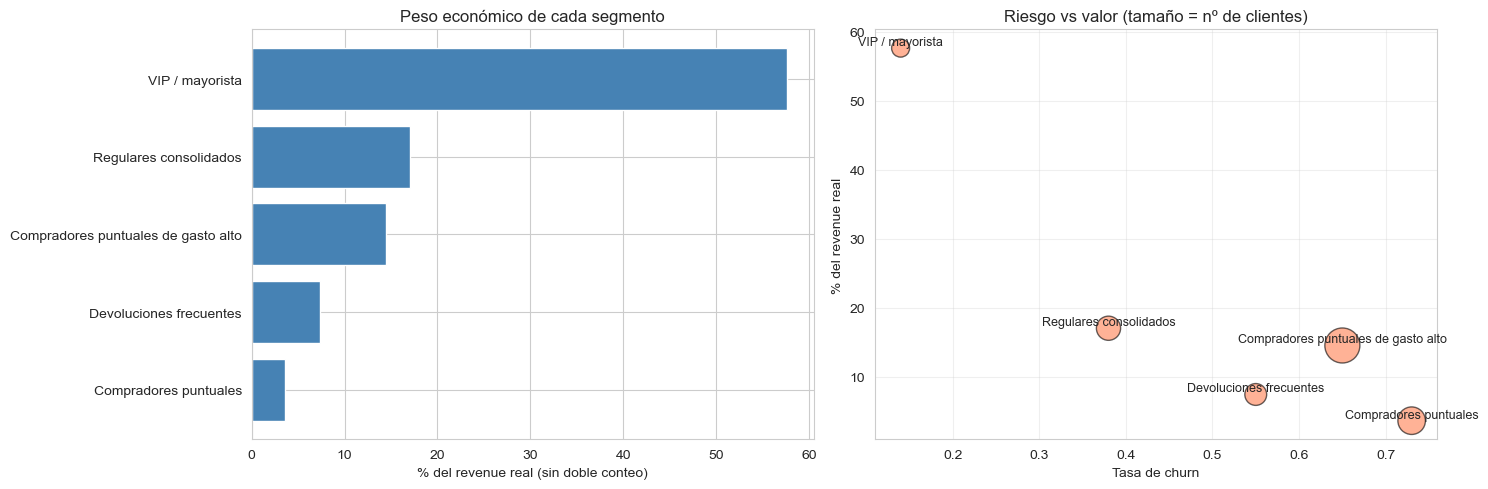

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
orden = perfil.sort_values('% revenue', ascending=False)

axes[0].barh(orden.segmento[::-1], orden['% revenue'][::-1], color='steelblue')
axes[0].set(xlabel='% del revenue real (sin doble conteo)', title='Peso económico de cada segmento')

axes[1].scatter(perfil.churn_rate, perfil['% revenue'], s=perfil.clientes / 3,
                alpha=0.6, color='coral', edgecolor='black')
for _, fila in perfil.iterrows():
    axes[1].annotate(fila.segmento, (fila.churn_rate, fila['% revenue']),
                     fontsize=9, ha='center', va='bottom')
axes[1].set(xlabel='Tasa de churn', ylabel='% del revenue real',
            title='Riesgo vs valor (tamaño = nº de clientes)')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Ventanas de intervención

Cuándo actuar. La recencia queda cuarta de siete por SHAP —y quinta por AUC univariante—,
pero es la única variable que responde a una pregunta distinta: no *a quién* contactar, sino **cuándo**.

Conviene ser explícito con la tensión que esto crea con la Fase 3b. Ordenar por riesgo
concentraría la campaña en los tramos de recencia alta, que son justamente los de **menor
gasto medio**: el tramo de 0-30 días acumula varias veces más libras por cliente que el de
60-90. Las dos lecturas no se contradicen si se le asigna a cada una su papel — **el valor
esperado elige al cliente, la recencia elige el momento** — y esa es exactamente la conclusión
operativa del trabajo.

In [10]:
tramos = pd.cut(test['recency_days'], [0, 30, 60, 90, 200], right=False,
                labels=['0-30 días', '30-60 días', '60-90 días', '90+ días'])
ventanas = test.groupby(tramos, observed=False).agg(
    clientes=('churn', 'size'), churn_rate=('churn', 'mean'), gasto_medio=('monetary', 'mean'),
).round(2)
ventanas['% de la base'] = (ventanas.clientes / ventanas.clientes.sum() * 100).round(1)

recomendacion = {
    '0-30 días': 'Activo. Sin acción de retención; comunicación comercial normal.',
    '30-60 días': 'Vigilar. Primera señal de enfriamiento — recomendaciones personalizadas.',
    '60-90 días': 'Ventana de máxima urgencia: el riesgo ya es alto y el cliente todavía es '
                  'recuperable. Urgencia no es prioridad — el gasto medio de este tramo es una '
                  'fracción del de los tramos recientes, así que a quién contactar lo sigue '
                  'decidiendo el valor esperado (Fase 3b); esto decide cuándo.',
    '90+ días': 'Reactivación tardía. Coste por recuperación mucho mayor; reservar para los de alto valor.',
}

print(ventanas.to_string())
RATIO_GASTO = ventanas.loc['0-30 días', 'gasto_medio'] / ventanas.loc['60-90 días', 'gasto_medio']
print(f"\nEl tramo de mayor riesgo NO es el de mayor valor: un cliente de 0-30 días gasta "
      f"{RATIO_GASTO:.1f}x más")
print("que uno de 60-90. Por eso la recencia fija el momento y el valor esperado elige "
      "al cliente.")
for tramo, texto in recomendacion.items():
    print(f"\n{tramo} (churn {ventanas.loc[tramo, 'churn_rate']:.0%}, "
          f"{ventanas.loc[tramo, '% de la base']:.0f}% de la base)")
    print(f"  {texto}")

              clientes  churn_rate  gasto_medio  % de la base
recency_days                                                 
0-30 días         5673        0.32      2505.24          32.6
30-60 días        3480        0.42      1026.34          20.0
60-90 días        2390        0.51       795.75          13.7
90+ días          5876        0.68       565.93          33.7

El tramo de mayor riesgo NO es el de mayor valor: un cliente de 0-30 días gasta 3.1x más
que uno de 60-90. Por eso la recencia fija el momento y el valor esperado elige al cliente.

0-30 días (churn 32%, 33% de la base)
  Activo. Sin acción de retención; comunicación comercial normal.

30-60 días (churn 42%, 20% de la base)
  Vigilar. Primera señal de enfriamiento — recomendaciones personalizadas.

60-90 días (churn 51%, 14% de la base)
  Ventana de máxima urgencia: el riesgo ya es alto y el cliente todavía es recuperable. Urgencia no es prioridad — el gasto medio de este tramo es una fracción del de los tramos reciente

## Explicación individual

Lo que necesita un gestor de cuenta: por qué *este* cliente tiene este score. El gráfico
descompone la predicción en la contribución de cada variable.

Un detalle de lectura que se presta a confusión: el signo del aporte depende del **valor del
cliente**, no del efecto global de la variable. `frequency` reduce el churn en toda la base,
pero para un cliente con una sola compra —muy por debajo de la media— su aporte *sube* el
riesgo. Por eso cada línea imprime el valor junto a la contribución.


Riesgo alto — cliente 15202 · P(churn)=91.7% · SE FUE (real)
  recencia 167d · 3 compras · £6,001 · 1 productos
    avg_items_per_transaction  =         1  (por debajo de la media 248)  ->  +0.80, sube el riesgo
    customer_age_days          =         0  (por debajo de la media 49)  ->  +0.44, sube el riesgo
    unique_products            =         1  (por debajo de la media 43)  ->  +0.40, sube el riesgo

Riesgo medio — cliente 13414 · P(churn)=37.5% · SE FUE (real)
  recencia 2d · 3 compras · £1,390 · 23 productos
    customer_age_days          =       162  (por encima de la media 49)  ->  -0.28, baja el riesgo
    monetary                   =     1,390  (por encima de la media 1,321)  ->  -0.21, baja el riesgo
    recency_days               =         2  (por debajo de la media 69)  ->  -0.13, baja el riesgo

Riesgo bajo — cliente 13089 · P(churn)=3.1% · SE QUEDÓ (real)
  recencia 0d · 46 compras · £35,687 · 387 productos
    frequency                  =        46  (por encima de l

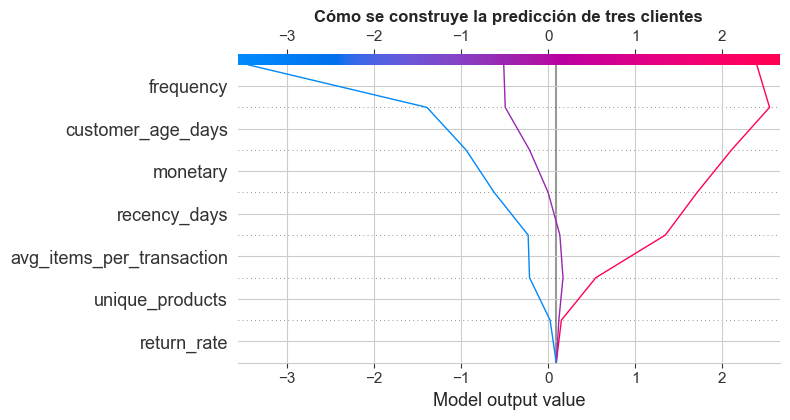

In [11]:
proba = modelo.predict_proba(X_test_s)[:, 1]
medias_test = test[FEATURES].mean()
casos = {
    'Riesgo alto': int(np.argmax(proba)),
    'Riesgo medio': int(np.argmin(np.abs(proba - THRESHOLD))),
    'Riesgo bajo': int(np.argmin(proba)),
}

for etiqueta, i in casos.items():
    fila = test.iloc[i]
    print(f"\n{etiqueta} — cliente {int(fila.CustomerID)} · P(churn)={proba[i]:.1%} · "
          f"{'SE FUE' if fila.churn == 1 else 'SE QUEDÓ'} (real)")
    print(f"  recencia {fila.recency_days:.0f}d · {fila.frequency:.0f} compras · "
          f"£{fila.monetary:,.0f} · {fila.unique_products:.0f} productos")
    aporte = pd.Series(shap_values[i], index=FEATURES).sort_values(key=abs, ascending=False)
    for f, v in aporte.head(3).items():
        # Se imprime el VALOR del cliente junto al aporte. Sin él la salida parece
        # contradecir la lectura global: `frequency` reduce el churn en toda la base,
        # pero UNA sola compra —muy por debajo de la media— lo sube para este cliente.
        nivel = 'por encima' if fila[f] > medias_test[f] else 'por debajo'
        print(f"    {f:26s} = {fila[f]:>9,.0f}  ({nivel} de la media {medias_test[f]:,.0f})"
              f"  ->  {v:+.2f}, {'sube' if v > 0 else 'baja'} el riesgo")

shap.decision_plot(base_value, shap_values[list(casos.values())],
                   feature_names=FEATURES, show=False)
plt.title('Cómo se construye la predicción de tres clientes', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Guardar

In [12]:
importancia.to_csv('../outputs/fase4_interpretability/feature_importance_fase4.csv', index=False)
perfil.to_csv('../outputs/fase4_interpretability/segment_summary_fase4.csv')
coefs.to_csv('../outputs/fase4_interpretability/logistic_coefficients_fase4.csv', index=False)
ventanas.to_csv('../outputs/fase4_interpretability/intervention_windows_fase4.csv')

with open('../models/interpretability_fase4.pkl', 'wb') as f:
    pickle.dump({'shap_values': shap_values, 'expected_value': base_value,
                 'feature_columns': FEATURES, 'segment_names': perfil['segmento'].to_dict()}, f)

for f in ['../outputs/fase4_interpretability/feature_importance_fase4.csv', '../outputs/fase4_interpretability/segment_summary_fase4.csv',
          '../outputs/fase4_interpretability/logistic_coefficients_fase4.csv', '../outputs/fase4_interpretability/intervention_windows_fase4.csv',
          '../models/interpretability_fase4.pkl']:
    print(f)

../outputs/fase4_interpretability/feature_importance_fase4.csv
../outputs/fase4_interpretability/segment_summary_fase4.csv
../outputs/fase4_interpretability/logistic_coefficients_fase4.csv
../outputs/fase4_interpretability/intervention_windows_fase4.csv
../models/interpretability_fase4.pkl
